## Predicting and auditing online purchase intention from completed web sessions

### A post-session conversion-driver audit

A post-session conversion-driver analysis using the UCI Online Shoppers dataset. The objective is a post-session audit: given a completed session, predict whether it converted and identify which behaviours drive conversion, so an analyst can review and learn from real sessions. The dataset carries no marketing channel, campaign or customer-identity fields, so no attribution claim is made.


[1] C. Sakar and Y. Kastro, “Online Shoppers Purchasing Intention Dataset,” UCI Machine Learning Repository, 2018. [Online]. Available: https://doi.org/10.24432/C5F88Q
[2] scikit-learn developers, "LogisticRegression," scikit-learn, 2026. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

# Section 1: The Data

## Imports and settings

A fixed `RANDOM_STATE` keeps the split, tuning and resampling reproducible.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
assert sklearn.__version__ >= "1.8", "l1_ratio penalty selection requires scikit-learn >= 1.8"
print("scikit-learn", sklearn.__version__)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    make_scorer, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scikit-learn 1.8.0


## Shared preprocessing, pipeline and tuning helpers

To keep the model experiments consistent and fair, small helper functions are defined once and reused throughout. `build_preprocessor` standardises the numeric columns and one-hot encodes the categorical ones, while `build_model_pipeline` wraps each model with a cloned preprocessor so every pipeline stays independent.

`build_random_search` then applies the same tuning design to each selected model: `F1` scoring, five-fold cross-validation, the same `random_state`, and parallel processing. 

In [74]:
def build_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
        ],
        sparse_threshold=0
    )

def build_model_pipeline(model, preprocessor):
    # clone keeps each pipeline independent
    return Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", model)
    ])

def build_random_search(pipeline, param_grid, n_iter):
    return RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="f1",
        cv=CV_STRATEGY,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

def clean_feature_names(names):
    return [name.replace("num__", "").replace("cat__", "") for name in names]

## Initial data examination

In [75]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


Each row represents a completed web session, with `Revenue` used as the binary purchase target. 

The input features combine browsing activity, such as page counts and durations, with engagement signals such as `BounceRates`, `ExitRates` and `PageValues`. 

The dataset also includes session context, including `Month`, `VisitorType` and `Weekend`, together with coded technical fields such as operating system, browser, region and traffic type.

## Initial inspection

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The dataset has 12,330 rows, 18 columns, no nulls reported.

The data contains a mixture of types: integers, floats, strings and Boolean values. Categorical and Boolean fields need encoding before modelling.

## Data quality: duplicates

Exact duplicates are inspected before any modelling decisions are made, because repeated rows can distort both class balance and model evaluation.

In [77]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(125)

In [78]:
duplicate_rows = df[df.duplicated(keep=False)].copy()

duplicate_rows_summary = pd.DataFrame({
    "duplicate_rows_including_originals": [len(duplicate_rows)],
    "duplicate_groups": [duplicate_rows.groupby(list(df.columns)).ngroups],
    "max_repeated_group_size": [
        duplicate_rows.groupby(list(df.columns)).size().max()
    ],
    "purchase_duplicates": [duplicate_rows["Revenue"].sum()],
    "non_purchase_duplicates": [(duplicate_rows["Revenue"] == False).sum()],
    "max_product_duration_in_duplicates": [
        duplicate_rows["ProductRelated_Duration"].max()
    ]
})

duplicate_rows_summary

,duplicate_rows_including_originals,duplicate_groups,max_repeated_group_size,purchase_duplicates,non_purchase_duplicates,max_product_duration_in_duplicates
0,201,76,14,0,201,0.0


The duplicate check found 201 rows involved in duplication, grouped into 76 repeated session patterns. After keeping one copy of each pattern, this means 125 rows would be removed. The largest repeated pattern appears 14 times.

All duplicated patterns are non-purchase sessions, and their maximum `ProductRelated_Duration` is 0. This suggests repeated empty or very short visits rather than additional behavioural evidence. 

*Design choice: Removing the duplicates will help to avoid strengthening the majority class with repeated non-purchase records, while keeping the modelling dataset focused on distinct session behaviour.*

In [79]:
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(12205, 18)

12,205 sessions remain. No purchase sessions were lost, so the imbalance is now slightly less extreme but still large, which shapes the validation strategy and metric choice later.

## Target imbalance

In [80]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10297,84.367063
True,1908,15.632937


Only 15.6% of sessions convert to `Revenue` (1,908 of 12,205). This class imbalance means accuracy could be misleading: a model that predicts “no purchase” for every session would still achieve about 84% accuracy, but would identify no buyers.

For this reason, accuracy is treated as a secondary measure. Model selection focuses on purchase-class precision, recall, F1-score and the confusion matrix, because these show how well the model identifies the smaller but more important purchase class.

In [81]:
scale_check = df.describe().loc[["min", "50%", "max", "std"]].T

scale_check = scale_check.rename(columns={"50%": "median"})
scale_check["range"] = scale_check["max"] - scale_check["min"]

scale_check.sort_values("range", ascending=False)

,min,median,max,std,range
ProductRelated_Duration,0.0,608.942857,63973.522230,1919.601400,63973.522230
Administrative_Duration,0.0,9.000000,3398.750000,177.491845,3398.750000
Informational_Duration,0.0,0.000000,2549.375000,141.424807,2549.375000
ProductRelated,0.0,18.000000,705.000000,44.593649,705.000000
PageValues,0.0,0.000000,361.763742,18.653671,361.763742
Administrative,0.0,1.000000,27.000000,3.330436,27.000000
Informational,0.0,0.000000,24.000000,1.275617,24.000000
TrafficType,1.0,2.000000,20.000000,4.016654,19.000000
Browser,1.0,2.000000,13.000000,1.710114,12.000000
Region,1.0,3.000000,9.000000,2.402340,8.000000


The scale check shows why standardisation is needed: `ProductRelated_Duration` reaches almost 64,000 seconds, while `BounceRates` and `ExitRates` stay between 0 and 0.2. Without scaling, models such as KNN, SVM and Logistic Regression could be pulled towards the largest-value features, motivating standardisation inside the pipeline rather than edits to the raw data.

In [82]:
df.sort_values("ProductRelated_Duration", ascending=False).head(10)[
    ["ProductRelated", "ProductRelated_Duration", "PageValues", "BounceRates", "ExitRates", "Revenue"]
]

,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates,Revenue
7983,449,63973.52223,0.000000,0.000764,0.027701,False
5074,705,43171.23338,0.763829,0.004851,0.015431,False
9149,343,29970.46597,0.000000,0.005316,0.028971,False
8695,517,27009.85943,8.403164,0.004385,0.014594,True
8220,584,24844.15620,4.511100,0.002099,0.009347,False
7574,414,23888.81000,1.033757,0.009900,0.027062,False
6599,686,23342.08205,0.150650,0.009853,0.022771,False
6080,486,23050.10414,0.000000,0.000324,0.011249,False
5831,439,21857.04648,11.439233,0.003589,0.012498,False
8883,501,21672.24425,9.131387,0.003965,0.014292,True


The longest `ProductRelated_Duration` values (~63,974 seconds, ~17.8 hours) are not duplicates. They carry distinct `ProductRelated`, `PageValues` and `rate` values. These seem to be long or idle-tab sessions, so they are retained rather than treated as errors.

In [83]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols],
    "most_common_percentage": [
        df[col].value_counts(normalize=True).iloc[0] * 100
        for col in categorical_cols
    ]
})

categorical_summary["most_common_percentage"] = (
    categorical_summary["most_common_percentage"].round(2)
)

categorical_summary

,unique_values,most_common_value,most_common_count,most_common_percentage
Month,10,May,3329,27.28
VisitorType,3,Returning_Visitor,10431,85.46
Weekend,2,False,9346,76.58
OperatingSystems,8,2,6541,53.59
Browser,13,2,7883,64.59
Region,9,1,4714,38.62
TrafficType,20,2,3911,32.04


The categorical and coded fields are unevenly distributed. `Returning_Visitor` accounts for 85.5% of sessions, while `Browser` value 2 and `OperatingSystems` value 2 account for 64.6% and 53.6%. Their integers are labels, not quantities, so they are one-hot encoded. The skew is also worth keeping in mind when interpreting one-hot feature scores later, because rare categories can carry limited evidence.

## Behavioural differences between buyers and non-buyers

In [84]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.999985,0.023197,0.045526,29.050403,1082.976881
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show a clear behavioural difference between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues` at 27.3 compared with 2.0, along with more product page visits, longer product browsing time and lower bounce and exit rates.

This suggests that browsing depth and page value may be useful predictors. `PageValues` does most of the separating, a point examined critically below before it is trusted.

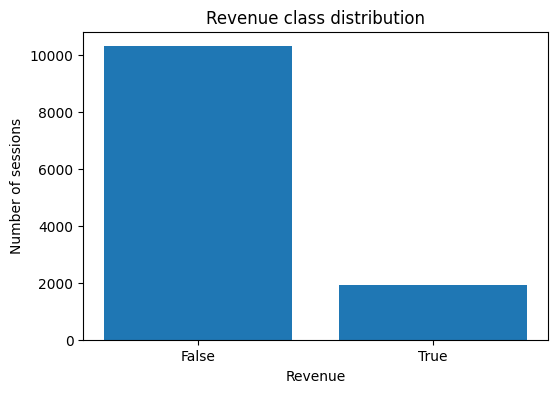

In [85]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

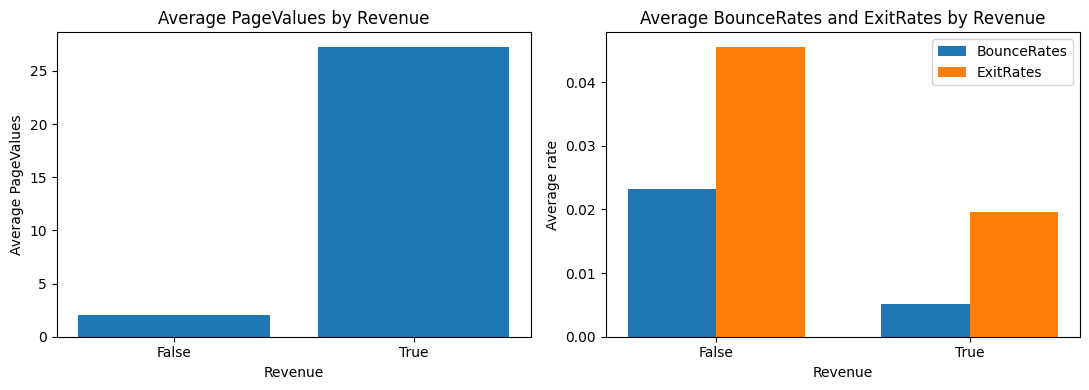

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()
axes[0].bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
axes[0].set_title("Average PageValues by Revenue")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Average PageValues")

rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()
x = np.arange(len(rate_means.index))
width = 0.35
axes[1].bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
axes[1].bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
axes[1].set_title("Average BounceRates and ExitRates by Revenue")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Average rate")
axes[1].set_xticks(x)
axes[1].set_xticklabels(rate_means.index.astype(str))
axes[1].legend()

plt.tight_layout()
plt.show()

The charts make the gap clear. Buyers have significantly higher `PageValues` and markedly lower bounce/exit rates. Visitors who stay and move through product pages convert more often, so engagement and exit behaviour are promising signals, therefore these features are carried forward into mutual information and permutation importance feature checks.

### A design note on `PageValues`

`PageValues` is a Google Analytics metric that represents the average value of pages a visitor saw before completing an e-commerce transaction [1]. In this project it is included deliberately, because the model is designed as a post-session audit using completed-session information.

Because `PageValues` is expected to be highly predictive, it is treated as a feature that needs interpretation. The later checks look at both model dependence on `PageValues` and the added value of wider behaviour signals such as `ExitRates`, `ProductRelated`, `BounceRates` and session timing.

## Preprocessing plan

The preprocessing is kept inside the modelling pipeline so each transform is fitted only on the training data used in that fold. This is the main leakage-control step.

Continuous numeric features are standardised because the duration variables are much larger than the rate features, which matters for `KNN`, `SVM` and `Logistic Regression`. The same preprocessing structure is used across models for consistency, even though tree-based models are not sensitive to feature scale. Categorical fields are one-hot encoded because values such as `Month`, `VisitorType`, `Browser` and `TrafficType` are labels rather than numeric measurements.

# Section 2: Constructing and Selecting Features

## Feature and target split

In [87]:
# Separate the input features from the target variable
X_original = df.drop(columns=["Revenue"])
y = df["Revenue"]

print("Feature data shape:", X_original.shape)
print("Target data shape:", y.shape)

Feature data shape: (12205, 17)
Target data shape: (12205,)


In [88]:
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features_original = [
    col for col in X_original.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features_original)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features before preprocessing. The UCI description groups the dataset into 10 numerical attributes and 8 categorical attributes [1]. `Weekend` is included with the categorical features because it describes the session type rather than a measured quantity. `OperatingSystems`, `Browser`, `Region` and `TrafficType` are also treated as categorical because their values are coded labels, not numbers with a meaningful order. The remaining ten fields are treated as numerical browsing-behaviour features, including page counts, page durations, Google Analytics rates, `PageValues` and `SpecialDay`.

In [89]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_original.shape)
print("Test features:", X_test_original.shape)
print("Training target:", y_train_original.shape)
print("Test target:", y_test_original.shape)

Training features: (9764, 17)
Test features: (2441, 17)
Training target: (9764,)
Test target: (2441,)


An 80/20 train-test split is used with `stratify=y`, keeping the 15.6% purchase rate consistent across both sets. This gives the models enough data to learn from, while keeping a held-out test set that reflects the original class balance. The test set is kept back until final evaluation.

In [90]:
split_balance = pd.DataFrame({
    "train_percentage": y_train_original.value_counts(normalize=True) * 100,
    "test_percentage": y_test_original.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.371159,84.350676
True,15.628841,15.649324


In [91]:
preprocessor_original = build_preprocessor(numerical_features_original, categorical_features)

print(preprocessor_original)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The original-feature preprocessor standardises the ten numerical columns and one-hot encodes the seven categorical columns. This gives every classifier the same all-numeric input while keeping the preprocessing logic in one shared pipeline.

## Filter-based feature selection: mutual information

Mutual information is computed on the training data only, so feature analysis never sees the test set. The aim is to map the strongest individual signals before modelling.

In [92]:
mi_preprocessor = clone(preprocessor_original)

X_train_processed = mi_preprocessor.fit_transform(X_train_original)
processed_feature_names = mi_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train_original,
    random_state=RANDOM_STATE
)

mi_scores_df = (
    pd.DataFrame({"feature": processed_feature_names, "mutual_information": mi_scores})
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_display_df = mi_scores_df.copy()
mi_scores_display_df["feature"] = clean_feature_names(mi_scores_display_df["feature"])
mi_scores_display_df.head(15)

,feature,mutual_information
0,PageValues,0.163820
1,ExitRates,0.037809
2,ProductRelated_Duration,0.032262
3,BounceRates,0.020914
4,ProductRelated,0.019765
5,Administrative,0.017184
6,Month_Nov,0.013419
7,SpecialDay,0.009886
8,TrafficType_15,0.009080
9,Administrative_Duration,0.008649


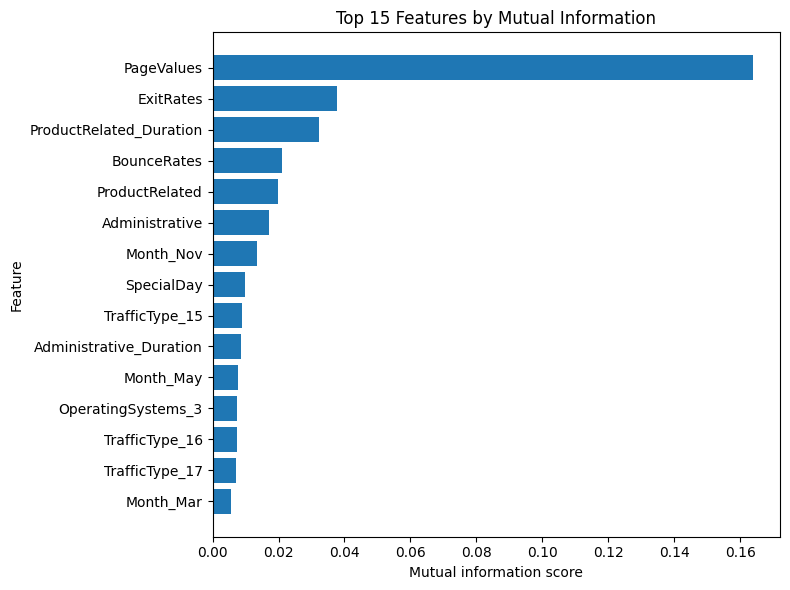

In [93]:
top_mi_features = mi_scores_display_df.head(15).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi_features["feature"], top_mi_features["mutual_information"])
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()

`PageValues` leads at 0.164, roughly four times the next feature. The rest of the top features are session-quality signals: `ExitRates` at 0.038, `ProductRelated_Duration` at 0.032, `BounceRates` at 0.021 and `ProductRelated` at 0.020.

One caveat is that mutual information is scored per one-hot column, so a multi-level field like `Month` is split across dummy variables and its overall signal may be understated here. This is checked later with model-based importance.

### SelectKBest and the feature-selection decision

`SelectKBest` applies the mutual information ranking as a formal filter-based feature selection step. It confirms which features would be retained under a top-k selection rule.

The final models still use the full feature set because lower-ranked variables may add value in combination with stronger predictors. Therefore, this step is used for feature analysis and interpretation rather than permanent feature removal.

In [94]:
TOP_K_FEATURES = 5

def reproducible_mutual_info(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE
    )

selected_feature_selector = SelectKBest(
    score_func=reproducible_mutual_info,
    k=TOP_K_FEATURES
)

selected_feature_selector.fit(X_train_processed, y_train_original)

selected_features_df = (
    pd.DataFrame({
        "selected_feature": processed_feature_names[selected_feature_selector.get_support()],
        "mutual_information": selected_feature_selector.scores_[selected_feature_selector.get_support()]
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

selected_features_df

,selected_feature,mutual_information
0,num__PageValues,0.163820
1,num__ExitRates,0.037809
2,num__ProductRelated_Duration,0.032262
3,num__BounceRates,0.020914
4,num__ProductRelated,0.019765


The selected features are all linked to completed-session behaviour. `PageValues` is the dominant feature, while `ExitRates`, `BounceRates`, `ProductRelated` and `ProductRelated_Duration` provide weaker but still relevant browsing-behaviour signals.

SelectKBest turns the mutual-information ranking into a formal top-k filter. With k = 5 it keeps PageValues, ExitRates, ProductRelated_Duration, BounceRates and ProductRelated, all of which are completed-session behaviour.

No features are dropped here. Mutual information scores each feature on its own, so lower-ranked features may still help when combined with others. Contextual fields such as `Month`, `VisitorType`, `TrafficType` and `Weekend` are also kept for possible seasonal or visitor pattern effects.

Whether a reduced set actually preserves performance is a model-level question, so it is tested in Section 3 once candidate models exist. At this point, the main takeaway is that the strongest individual signals are session activity features, which is where the later feature-engineering cycle focuses.

# Section 3: Building ML Algorithms


This is a supervised binary classification task because each session has a known `Revenue` label.

Eight classifiers span the main families so the comparison is not tied to one assumption: linear (`Logistic Regression`), kernel (`Support Vector Machine`), instance-based (`K-Nearest Neighbours`), single-tree (`Decision Tree`), bagged and boosted ensembles (`Random Forest`, `Gradient Boosting`, `Hist Gradient Boosting`) and a neural network (`MLPClassifier`).

## 3.1 Baseline comparison: controlled algorithm comparison

The baseline models are run without class weighting so the first comparison uses the same basic setup for every classifier. This keeps the screen focused on the algorithms themselves, rather than mixing algorithm performance with different imbalance-handling options. Class imbalance is still accounted for through the evaluation metrics, then handled more directly during tuning.

A shared evaluation helper reports the confusion matrix and purchase-class precision, recall and F1-score for every model.

In [95]:
def evaluate_model(model_name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, y_pred, cm

In [96]:
# Baseline models: no class weighting, so the screen is like-for-like across families.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLPClassifier": MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
}

In [97]:
baseline_results = []
trained_pipelines = {}
baseline_predictions = {}
baseline_confusion_matrices = {}

for model_name, model in models.items():
    pipeline = build_model_pipeline(clone(model), preprocessor_original)

    pipeline.fit(X_train_original, y_train_original)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_original,
        y_test_original
    )

    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline
    baseline_predictions[model_name] = y_pred
    baseline_confusion_matrices[model_name] = cm



Logistic Regression
Confusion matrix:
[[2007   52]
 [ 224  158]]

Classification report:
              precision    recall  f1-score   support

       False       0.90      0.97      0.94      2059
        True       0.75      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.73      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
Confusion matrix:
[[1875  184]
 [ 166  216]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.91      0.91      2059
        True       0.54      0.57      0.55       382

    accuracy                           0.86      2441
   macro avg       0.73      0.74      0.73      2441
weighted avg       0.86      0.86      0.86      2441


Random Forest
Confusion matrix:
[[1994   65]
 [ 170  212]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [98]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590
2,Random Forest,0.903728,0.765343,0.554974,0.643399
4,Support Vector Machine,0.895535,0.736059,0.518325,0.608295
7,MLPClassifier,0.878329,0.617729,0.583770,0.600269
1,Decision Tree,0.856616,0.540000,0.565445,0.552430
0,Logistic Regression,0.886932,0.752381,0.413613,0.533784
3,K-Nearest Neighbours,0.873413,0.662222,0.390052,0.490939


On the unweighted baseline screen, the boosting models lead on purchase-class F1, the score used here to balance how many buyers are found with how many purchase predictions are correct. `Hist Gradient Boosting` scores 0.674 and `Gradient Boosting` scores 0.668.

The precision and recall split shows why tuning is needed. `Random Forest` has strong precision but lower recall at P 0.765 / R 0.555, while `Logistic Regression` at P 0.752 / R 0.414 and `SVM` at P 0.736 / R 0.518 are even more cautious. They make relatively accurate purchase predictions when they do predict purchase, but miss many actual buyers. This is the gap that class weighting targets during tuning.

`Gradient Boosting`, `Hist Gradient Boosting`, `Random Forest`, `SVM`, `Logistic Regression` and `MLPClassifier` are carried forward for tuning. `MLPClassifier` is included as a different model family, with tuning used to address the convergence warning from the baseline run.

## 3.2 Exploratory model-based importance

Gradient Boosting gives a quick model-side view of feature importance before tuning. This is exploratory, because built-in importance is model-specific and one-hot encoded fields are split across separate dummy columns.

In [99]:
gb_pipeline = trained_pipelines["Gradient Boosting"]

gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]
feature_names = gb_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,num__PageValues,0.746017
17,cat__Month_Nov,0.044649
6,num__BounceRates,0.043008
5,num__ProductRelated_Duration,0.034506
0,num__Administrative,0.030777
7,num__ExitRates,0.025386
1,num__Administrative_Duration,0.014230
4,num__ProductRelated,0.013252
16,cat__Month_May,0.008298
22,cat__VisitorType_Returning_Visitor,0.006751


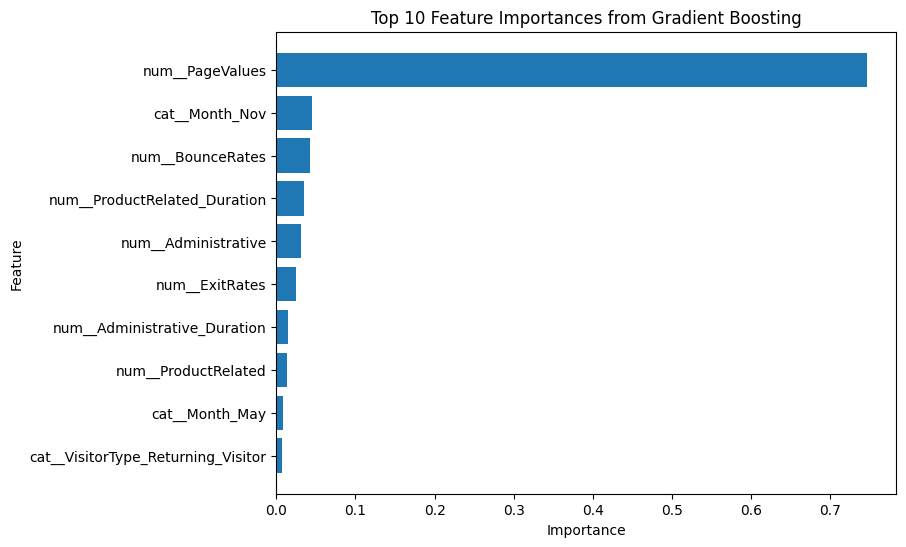

In [100]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

`PageValues` dominates again, but the next features add useful context. `Month_Nov`, `BounceRates`, `ProductRelated_Duration`, `Administrative` and `ExitRates` all appear in the top group. The presence of `Month_Nov` and `Month_May` suggests that the original `Month` field may carry more signal than the mutual-information chart showed, because its effect is divided across individual month columns. This is checked later with permutation importance on the final contenders.

### Diagnostic: how much does the model lean on `PageValues`?

This check tests the `PageValues` design issue directly: the same `Gradient Boosting` model is cross-validated on the training data once with `PageValues` and once without it.

In [101]:
X_train_with_pagevalues = X_train_original.copy()
X_train_without_pagevalues = X_train_original.drop(columns=["PageValues"])

numerical_features_without_pagevalues = [
    col for col in numerical_features_original
    if col != "PageValues"
]

preprocessor_with_pagevalues = build_preprocessor(numerical_features_original, categorical_features)
preprocessor_without_pagevalues = build_preprocessor(numerical_features_without_pagevalues, categorical_features)

# Same model used in both experiments
gb_with_pagevalues_pipeline = build_model_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_with_pagevalues
)
gb_without_pagevalues_pipeline = build_model_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_without_pagevalues
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_with_pagevalues = cross_validate(
    gb_with_pagevalues_pipeline,
    X_train_with_pagevalues,
    y_train_original,
    cv=CV_STRATEGY,
    scoring=scoring,
    n_jobs=-1
)

cv_without_pagevalues = cross_validate(
    gb_without_pagevalues_pipeline,
    X_train_without_pagevalues,
    y_train_original,
    cv=CV_STRATEGY,
    scoring=scoring,
    n_jobs=-1
)

pagevalues_cv_comparison = pd.DataFrame({
    "With PageValues": [
        cv_with_pagevalues["test_accuracy"].mean(),
        cv_with_pagevalues["test_precision"].mean(),
        cv_with_pagevalues["test_recall"].mean(),
        cv_with_pagevalues["test_f1"].mean()
    ],
    "Without PageValues": [
        cv_without_pagevalues["test_accuracy"].mean(),
        cv_without_pagevalues["test_precision"].mean(),
        cv_without_pagevalues["test_recall"].mean(),
        cv_without_pagevalues["test_f1"].mean()
    ]
}, index=["accuracy", "precision", "recall", "f1"])

pagevalues_cv_comparison["Difference"] = (
    pagevalues_cv_comparison["Without PageValues"]
    - pagevalues_cv_comparison["With PageValues"]
)

pagevalues_cv_comparison

,With PageValues,Without PageValues,Difference
accuracy,0.902295,0.845862,-0.056432
precision,0.728542,0.550415,-0.178126
recall,0.598290,0.079310,-0.518980
f1,0.656746,0.138221,-0.518525


Removing `PageValues` changes the model completely. F1 falls from 0.656 to 0.138, and recall falls from 0.598 to 0.079, while accuracy only drops by 0.056. This shows why accuracy is not enough for this task: the model can still classify most non-purchase sessions correctly, but almost stop finding buyers.

`PageValues` is kept because it fits the post-session design. The session has already finished, so the analyst can use the value of pages visited before a transaction as part of the review. The key point is not only that `PageValues` improves performance, but how strongly the model relies on it. The next step checks whether other behaviour signals, such as `ExitRates`, `BounceRates`, `ProductRelated` and session timing, still add value.

## 3.3 Original-feature tuning

The strongest baseline candidates are tuned with `RandomizedSearchCV`, five-fold cross-validation and `scoring="f1"`, because F1 balances how many buyers are found with how many purchase predictions are correct. Random search is used instead of grid search because it allows a wider range of parameter values to be tested within the same compute budget.

Each model uses the same five-fold stratified, shuffled cross-validation and the same seed, defined once in `CV_STRATEGY`. Each search samples up to a set number of configurations, and any grid smaller than that is searched in full, so smaller models are not under-tuned relative to larger ones.

Class imbalance is handled during tuning by testing `class_weight="balanced"` where the model supports it, alongside the other hyperparameters.

### Tuning Gradient Boosting

In [102]:
gb_pipeline = build_model_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_original)

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}

gb_search = build_random_search(gb_pipeline, gb_param_grid, n_iter=6)
gb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(gb_search.best_params_)

print("Best cross-validation F1-score:")
print(gb_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best cross-validation F1-score:
0.654293105610568


In [103]:
# Initialise the tuned results list once
tuned_results = []

gb_tuned_results, gb_tuned_pred, gb_tuned_confusion = evaluate_model(
    "Tuned Gradient Boosting", gb_search, X_test_original, y_test_original
)
tuned_results.append(gb_tuned_results)
gb_tuned_results


Tuned Gradient Boosting
Confusion matrix:
[[1961   98]
 [ 136  246]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.80      0.81      2441
weighted avg       0.90      0.90      0.90      2441



{'model': 'Tuned Gradient Boosting',
 'accuracy': 0.9041376485047112,
 'precision': 0.7151162790697675,
 'recall': 0.643979057591623,
 'f1': 0.6776859504132231}

`Tuned Gradient Boosting` improves slightly over baseline, moving from F1 `0.668` to `0.675` with `200` boosting stages, `max_depth=3` and `learning_rate=0.05`. It is ruled in as a precision-leaning contender.

### Tuning Hist Gradient Boosting

In [104]:
hgb_pipeline = build_model_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_original)

hgb_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.1]
}

hgb_search = build_random_search(hgb_pipeline, hgb_param_grid, n_iter=6)
hgb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(hgb_search.best_params_)

print("Best cross-validation F1-score:")
print(hgb_search.best_score_)

hgb_tuned_results, hgb_tuned_pred, hgb_tuned_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting", hgb_search, X_test_original, y_test_original
)
tuned_results.append(hgb_tuned_results)

Best parameters:
{'model__max_leaf_nodes': 15, 'model__max_iter': 200, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.1}
Best cross-validation F1-score:
0.6643238785188639

Tuned Hist Gradient Boosting
Confusion matrix:
[[1963   96]
 [ 143  239]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.63      0.67       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441



`Tuned Hist Gradient Boosting` drops slightly against baseline, moving from F1 `0.674` to `0.668` with `max_leaf_nodes=15`, `max_iter=100` and `learning_rate=0.05`. It is ruled out as the lead boosting model, but kept in the comparison table.

### Tuning Support Vector Machine

In [105]:
svm_pipeline = build_model_pipeline(SVC(random_state=RANDOM_STATE), preprocessor_original)

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_search = build_random_search(svm_pipeline, svm_param_grid, n_iter=12)
svm_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(svm_search.best_params_)
print("\nBest CV F1-score:")
print(svm_search.best_score_)

svm_tuned_results, svm_tuned_pred, svm_tuned_confusion = evaluate_model(
    "Tuned Support Vector Machine", svm_search, X_test_original, y_test_original
)
tuned_results.append(svm_tuned_results)

Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1-score:
0.6550471941876432

Tuned Support Vector Machine
Confusion matrix:
[[1833  226]
 [  86  296]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



`Tuned Support Vector Machine` improves over baseline, moving from F1 `0.608` to `0.653` with `kernel='rbf'`, `C=10`, `gamma=0.01` and `class_weight='balanced'`. It is ruled out as the main model because recall is strong at `0.77`, but precision stays lower at `0.57`.

### Tuning Logistic Regression

Logistic Regression is the interpretable linear comparator. Using the scikit-learn 1.8 API, `l1_ratio` sets the penalty directly (`0` is L2, `1` is L1, `0.5` is an even elastic-net mix) and is tuned alongside `C`, so the model can move between ridge, lasso and intermediate solutions and the surviving coefficients can be read directly [2].

In [106]:
# scikit-learn 1.8+ uses l1_ratio instead of the deprecated penalty argument [2].
# l1_ratio controls the regularisation mix: 0 = L2, 1 = L1, between 0 and 1 = Elastic Net.
# solver='saga' is used because it supports this full regularisation range.
logreg_pipeline = build_model_pipeline(
    LogisticRegression(
        solver="saga",
        l1_ratio=0.0,
        C=1.0,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    preprocessor_original
)

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0.0, 0.5, 1.0]
}

logreg_search = build_random_search(logreg_pipeline, logreg_param_grid, n_iter=8)
logreg_search.fit(X_train_original, y_train_original)

print("Best parameters:", logreg_search.best_params_)
print("Best CV F1-score:", logreg_search.best_score_)

logreg_tuned_results, logreg_tuned_pred, logreg_tuned_confusion = evaluate_model(
    "Tuned Logistic Regression", logreg_search, X_test_original, y_test_original
)
tuned_results.append(logreg_tuned_results)

Best parameters: {'model__l1_ratio': 1.0, 'model__C': 0.01}
Best CV F1-score: 0.6495853300044673

Tuned Logistic Regression
Confusion matrix:
[[1853  206]
 [  94  288]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2059
        True       0.58      0.75      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.79      2441
weighted avg       0.89      0.88      0.88      2441



`Tuned Logistic Regression` improves clearly over baseline, moving from F1 `0.534` to `0.655` with `C=0.01` and `l1_ratio=1.0`. It is ruled in as the interpretable benchmark, with recall `0.75` and directly readable coefficients, even though the ensembles remain stronger overall.

In [107]:
best_l1 = logreg_search.best_params_["model__l1_ratio"]
logreg_coef = logreg_search.best_estimator_.named_steps["model"].coef_.ravel()
zeroed = int((logreg_coef == 0).sum())
print(f"Selected l1_ratio: {best_l1} ({zeroed} of {logreg_coef.size} coefficients driven to zero)")

Selected l1_ratio: 1.0 (65 of 74 coefficients driven to zero)


The search selected `l1_ratio = 1.0`, so this Logistic Regression model used `L1` regularisation. This reduced the model to a small set of active predictors by setting `65 of the 74 coefficients` to zero, so the coefficient interpretation in `4.5` focuses only on the features still being used by the model.

### Tuning Random Forest

In [108]:
rf_pipeline = build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE), preprocessor_original)

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}
rf_search = build_random_search(rf_pipeline, rf_param_grid, n_iter=30)
rf_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(rf_search.best_params_)
print("\nBest CV F1-score:")
print(rf_search.best_score_)

rf_tuned_results, rf_tuned_pred, rf_tuned_confusion = evaluate_model(
    "Tuned Random Forest",
    rf_search,
    X_test_original,
    y_test_original
)

tuned_results.append(rf_tuned_results)

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1-score:
0.6805307891788474

Tuned Random Forest
Confusion matrix:
[[1927  132]
 [ 116  266]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.67      0.70      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.82      0.81      2441
weighted avg       0.90      0.90      0.90      2441



`Tuned Random Forest` improves over baseline, moving from F1 `0.643` to `0.684` with `300` trees, `max_depth=20`, `min_samples_leaf=2` and `class_weight='balanced'`. It is ruled in as the recall-leaning contender, finding `266` buyers with recall `0.70`.

### Tuning MLPClassifier

In [109]:
mlp_pipeline = build_model_pipeline(
    MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
    preprocessor_original
)

mlp_param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__activation": ["relu", "tanh"]
}

mlp_search = build_random_search(mlp_pipeline, mlp_param_grid, n_iter=10)
mlp_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(mlp_search.best_params_)
print("\nBest CV F1-score:")
print(mlp_search.best_score_)

mlp_tuned_results, mlp_tuned_pred, mlp_tuned_confusion = evaluate_model(
    "Tuned MLPClassifier", mlp_search, X_test_original, y_test_original
)
tuned_results.append(mlp_tuned_results)

Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (50, 25), 'model__alpha': 0.01, 'model__activation': 'tanh'}

Best CV F1-score:
0.6385924658852798

Tuned MLPClassifier
Confusion matrix:
[[1979   80]
 [ 170  212]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.96      0.94      2059
        True       0.73      0.55      0.63       382

    accuracy                           0.90      2441
   macro avg       0.82      0.76      0.78      2441
weighted avg       0.89      0.90      0.89      2441



`Tuned MLPClassifier` improves over baseline, moving from F1 `0.600` to `0.644` with one hidden layer of `50`, `activation='relu'`, `alpha=0.01` and `learning_rate_init=0.01`. It is ruled out as a lead model because the tuned tree ensembles still give stronger F1 and recall on this tabular dataset.

### Comparing the original-feature tuned models

In [110]:
# drop_duplicates guards against a model being appended twice if a tuning cell is re-run.
tuned_results_df = pd.DataFrame(tuned_results).drop_duplicates(subset="model").reset_index(drop=True)
tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
4,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051
0,Tuned Gradient Boosting,0.904138,0.715116,0.643979,0.677686
1,Tuned Hist Gradient Boosting,0.902089,0.713433,0.625654,0.666667
3,Tuned Logistic Regression,0.877100,0.582996,0.753927,0.657534
2,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867
5,Tuned MLPClassifier,0.897583,0.726027,0.554974,0.629080


Across the original-feature tuning, `Tuned Random Forest` leads on F1 at `0.682` and has the strongest tree-model recall at `0.696`. `Tuned Gradient Boosting` is close behind at F1 `0.675`, with higher precision at `0.719`.

`Tuned Random Forest` and `Tuned Gradient Boosting` are taken forward as the two design poles: one stronger for finding buyers, the other more selective when flagging likely purchases.

## 3.4 Feature engineering cycle

The earlier analysis and mutual information results pointed to session depth and product focus, so four summary engineered features are tested to see whether reshaping existing behaviour improves the models or provides clearer interpretation.

Four engineered features are added:

`total_pages`: total number of administrative, informational and product-related pages viewed.

`total_duration`: total time spent across administrative, informational and product-related pages.

`product_page_ratio`: proportion of viewed pages that were product-related.

`product_duration_ratio`: proportion of recorded browsing time spent on product-related pages.

### Create engineered session features

In [111]:
df_engineered = df.copy()

page_count_columns = ["Administrative", "Informational", "ProductRelated"]
duration_columns = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]

df_engineered["total_pages"] = df_engineered[page_count_columns].sum(axis=1)

df_engineered["total_duration"] = df_engineered[duration_columns].sum(axis=1)

df_engineered["product_page_ratio"] = np.where(
    df_engineered["total_pages"] > 0,
    df_engineered["ProductRelated"] / df_engineered["total_pages"],
    0
)

df_engineered["product_duration_ratio"] = np.where(
    df_engineered["total_duration"] > 0,
    df_engineered["ProductRelated_Duration"] / df_engineered["total_duration"],
    0
)

engineered_feature_names = [
    "total_pages",
    "total_duration",
    "product_page_ratio",
    "product_duration_ratio"
]

df_engineered[engineered_feature_names].describe()

,total_pages,total_duration,product_page_ratio,product_duration_ratio
count,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,1323.454242,0.904126,0.851437
std,46.627336,2043.871589,0.142281,0.255850
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,231.666667,0.857143,0.831101
50%,20.000000,690.958333,0.961538,0.968646
75%,42.000000,1643.958333,1.000000,1.000000
max,746.000000,69921.647230,1.000000,1.000000


`total_pages` and `total_duration` are heavily skewed, with maximum values of `746` pages and `69,922` seconds. The ratio features cluster near `1`, with medians of `0.962` and `0.969`, so most sessions are already product-focused.

The ratio features may add limited new signal, but they give a clear measure of session focus and are worth testing.

### Train-test split with engineered features

In [112]:
X_engineered = df_engineered.drop(columns=["Revenue"])
y_engineered = df_engineered["Revenue"]

numerical_features_engineered = [
    col for col in X_engineered.columns
    if col not in categorical_features
]

X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    stratify=y_engineered,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_engineered.shape)
print("Test features:", X_test_engineered.shape)

Training features: (9764, 21)
Test features: (2441, 21)


The same `80/20` stratified split is used, giving `9,764` training rows and `2,441` test rows. Holding the split constant keeps the two cycles directly comparable.

### Mutual information with engineered features


In [113]:
preprocessor_engineered = build_preprocessor(numerical_features_engineered, categorical_features)

mi_preprocessor = clone(preprocessor_engineered)
X_train_processed_eng = mi_preprocessor.fit_transform(X_train_engineered)
processed_feature_names_eng = mi_preprocessor.get_feature_names_out()

mi_scores_eng = mutual_info_classif(X_train_processed_eng, y_train_engineered, random_state=RANDOM_STATE)

mi_scores_engineered_display_df = (
    pd.DataFrame({
        "feature": clean_feature_names(processed_feature_names_eng),
        "mutual_information": mi_scores_eng
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

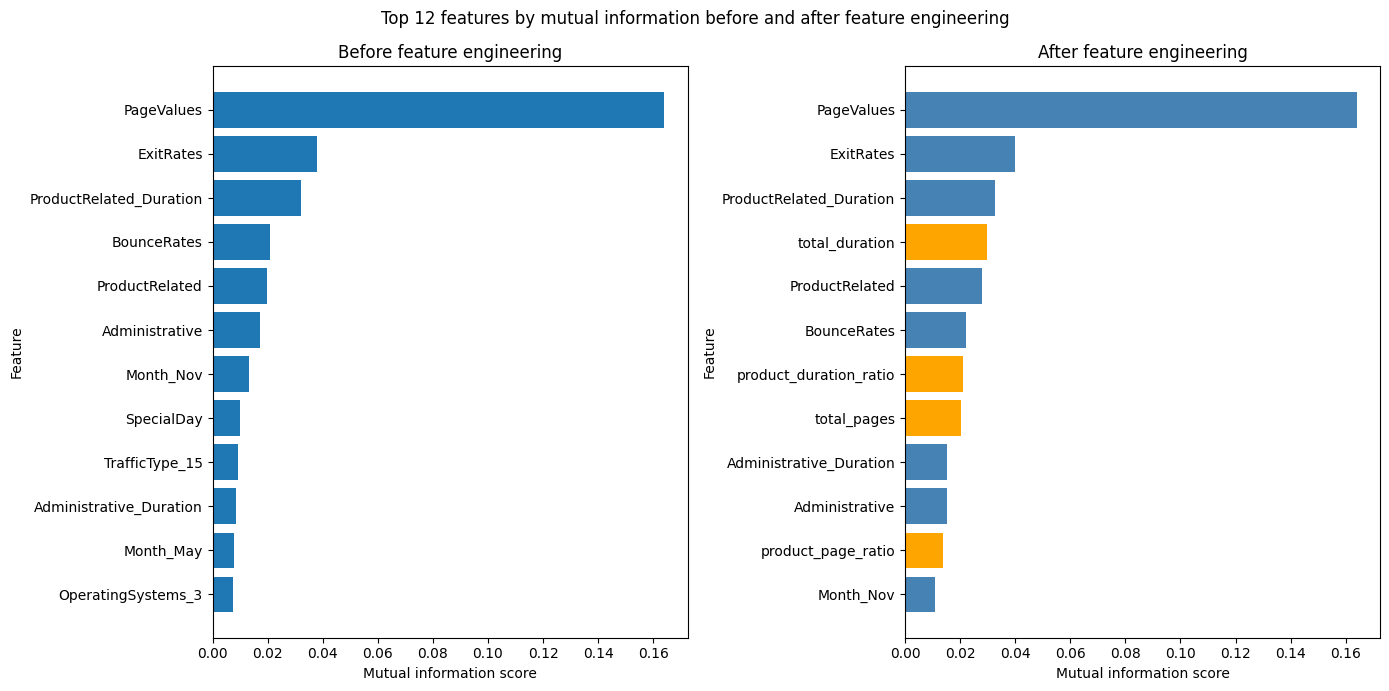

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

top_mi_original_features = (
    mi_scores_display_df
    .head(12)
    .sort_values("mutual_information")
)

top_mi_engineered_features = (
    mi_scores_engineered_display_df
    .head(12)
    .sort_values("mutual_information")
)

axes[0].barh(
    top_mi_original_features["feature"],
    top_mi_original_features["mutual_information"]
)
axes[0].set_title("Before feature engineering")
axes[0].set_xlabel("Mutual information score")
axes[0].set_ylabel("Feature")

engineered_colours = [
    "orange" if feature in engineered_feature_names else "steelblue"
    for feature in top_mi_engineered_features["feature"]
]

axes[1].barh(
    top_mi_engineered_features["feature"],
    top_mi_engineered_features["mutual_information"],
    color=engineered_colours
)
axes[1].set_title("After feature engineering")
axes[1].set_xlabel("Mutual information score")
axes[1].set_ylabel("Feature")

plt.suptitle("Top 12 features by mutual information before and after feature engineering")
plt.tight_layout()
plt.show()

`PageValues` still leads at `0.164`, with `ExitRates` next at `0.040` and `ProductRelated_Duration` at `0.033`. All four engineered features enter the top twelve: `total_duration` at `0.030`, `product_duration_ratio` at `0.021`, `total_pages` at `0.020` and `product_page_ratio` at `0.014`.

The engineered features carry individual signal, but mutual information scores each feature on its own. The model-level value is tested next.

### Baseline modelling with engineered features

In [115]:
engineered_baseline_results = []
engineered_trained_pipelines = {}

for model_name, model in models.items():
    pipeline = build_model_pipeline(clone(model), preprocessor_engineered)

    pipeline.fit(X_train_engineered, y_train_engineered)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_engineered,
        y_test_engineered
    )

    engineered_baseline_results.append(results)
    engineered_trained_pipelines[model_name] = pipeline

engineered_baseline_results_df = pd.DataFrame(engineered_baseline_results)
engineered_baseline_results_df.sort_values(by="f1", ascending=False)


Logistic Regression
Confusion matrix:
[[2010   49]
 [ 225  157]]

Classification report:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94      2059
        True       0.76      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.74      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
Confusion matrix:
[[1880  179]
 [ 157  225]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.91      0.92      2059
        True       0.56      0.59      0.57       382

    accuracy                           0.86      2441
   macro avg       0.74      0.75      0.75      2441
weighted avg       0.87      0.86      0.86      2441


Random Forest
Confusion matrix:
[[1998   61]
 [ 183  199]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.901680,0.712575,0.623037,0.664804
6,Hist Gradient Boosting,0.898812,0.702703,0.612565,0.654545
2,Random Forest,0.900041,0.765385,0.520942,0.619938
4,Support Vector Machine,0.895535,0.745174,0.505236,0.602184
7,MLPClassifier,0.872184,0.598870,0.554974,0.576087
1,Decision Tree,0.862351,0.556931,0.589005,0.572519
0,Logistic Regression,0.887751,0.762136,0.410995,0.534014
3,K-Nearest Neighbours,0.868497,0.624490,0.400524,0.488038


The engineered baseline keeps the same pattern: `Gradient Boosting` leads at F1 `0.665`, followed by `Hist Gradient Boosting` at `0.655`. `Random Forest` remains more precision-leaning, with precision `0.765` but recall `0.521`. This screening selects which engineered models to tune rather than assuming the new features help.

### Tuning engineered-feature models

`Gradient Boosting`, `Hist Gradient Boosting` and `Random Forest` are the top three engineered baselines by F1. `Logistic Regression` is also tuned as the interpretable comparator, while the remaining lower-ranked models are not retuned in this cycle.

The engineered cycle reuses the original grids, search budgets and cross-validation, so the only variable between the cycles is the feature set. This keeps the comparison a clean feature-only experiment.


In [116]:
engineered_tuned_results = []
engineered_tuned_models = {}

### Gradient Boosting: strongest engineered contender

In [117]:
gb_engineered_pipeline = build_model_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_engineered)
gb_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}
gb_engineered_search = build_random_search(gb_engineered_pipeline, gb_engineered_param_grid, n_iter=6)
gb_engineered_search.fit(X_train_engineered, y_train_engineered)

gb_engineered_best_model = gb_engineered_search.best_estimator_

gb_engineered_results, gb_engineered_pred, gb_engineered_confusion = evaluate_model(
    "Tuned Gradient Boosting engineered",
    gb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)
engineered_tuned_results.append(gb_engineered_results)
engineered_tuned_models["Tuned Gradient Boosting engineered"] = gb_engineered_best_model
print(gb_engineered_search.best_params_, gb_engineered_search.best_score_)


Tuned Gradient Boosting engineered
Confusion matrix:
[[1960   99]
 [ 143  239]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.63      0.66       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441

{'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1} 0.6549301193428195


### Hist Gradient Boosting: close engineered contender

In [118]:
hgb_engineered_pipeline = build_model_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_engineered)
hgb_engineered_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.001]
}
hgb_engineered_search = build_random_search(hgb_engineered_pipeline, hgb_engineered_param_grid, n_iter=6)
hgb_engineered_search.fit(X_train_engineered, y_train_engineered)

hgb_engineered_best_model = hgb_engineered_search.best_estimator_

hgb_engineered_results, hgb_engineered_pred, hgb_engineered_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting engineered",
    hgb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(hgb_engineered_results)
engineered_tuned_models["Tuned Hist Gradient Boosting engineered"] = hgb_engineered_best_model
print(hgb_engineered_search.best_params_, hgb_engineered_search.best_score_)


Tuned Hist Gradient Boosting engineered
Confusion matrix:
[[1961   98]
 [ 141  241]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.63      0.67       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441

{'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0} 0.6596500157755092


### Random Forest: original benchmark retested with engineered features

In [119]:
rf_engineered_pipeline = build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE), preprocessor_engineered)
rf_engineered_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}
rf_engineered_search = build_random_search(rf_engineered_pipeline, rf_engineered_param_grid, n_iter=30)
rf_engineered_search.fit(X_train_engineered, y_train_engineered)

rf_engineered_best_model = rf_engineered_search.best_estimator_

rf_engineered_results, rf_engineered_pred, rf_engineered_confusion = evaluate_model(
    "Tuned Random Forest engineered",
    rf_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(rf_engineered_results)
engineered_tuned_models["Tuned Random Forest engineered"] = rf_engineered_best_model
print(rf_engineered_search.best_params_, rf_engineered_search.best_score_)


Tuned Random Forest engineered
Confusion matrix:
[[1935  124]
 [ 130  252]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.67      0.66      0.66       382

    accuracy                           0.90      2441
   macro avg       0.80      0.80      0.80      2441
weighted avg       0.90      0.90      0.90      2441

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'} 0.6792744272960222


### Logistic Regression: interpretable engineered comparator

In [120]:
# scikit-learn 1.8+ uses l1_ratio instead of the deprecated penalty argument [2].
# l1_ratio controls the regularisation mix: 0 = L2, 1 = L1, between 0 and 1 = Elastic Net.
# solver='saga' is used because it supports this full regularisation range.
logreg_engineered_pipeline = build_model_pipeline(
    LogisticRegression(
        solver="saga",
        l1_ratio=0.0,
        C=1.0,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    preprocessor_engineered
)
logreg_engineered_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0.0, 0.5, 1.0]
}

logreg_engineered_search = build_random_search(logreg_engineered_pipeline, logreg_engineered_param_grid, n_iter=8)
logreg_engineered_search.fit(X_train_engineered, y_train_engineered)

logreg_engineered_best_model = logreg_engineered_search.best_estimator_

logreg_engineered_results, logreg_engineered_pred, logreg_engineered_confusion = evaluate_model(
    "Tuned Logistic Regression engineered",
    logreg_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)
engineered_tuned_results.append(logreg_engineered_results)
engineered_tuned_models["Tuned Logistic Regression engineered"] = logreg_engineered_best_model

print("Best parameters:", logreg_engineered_search.best_params_)
print("Best CV F1-score:", logreg_engineered_search.best_score_)


Tuned Logistic Regression engineered
Confusion matrix:
[[1839  220]
 [  89  293]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441

Best parameters: {'model__l1_ratio': 1.0, 'model__C': 0.01}
Best CV F1-score: 0.6441257373402108


### Comparing engineered-feature contenders

In [121]:
engineered_tuned_results_df = (pd.DataFrame(engineered_tuned_results).drop_duplicates(subset="model", keep="last"))

engineered_tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
1,Tuned Hist Gradient Boosting engineered,0.902089,0.710914,0.630890,0.668516
2,Tuned Random Forest engineered,0.895944,0.670213,0.659686,0.664908
0,Tuned Gradient Boosting engineered,0.900860,0.707101,0.625654,0.663889
3,Tuned Logistic Regression engineered,0.873413,0.571150,0.767016,0.654749


Within the engineered cycle, the tuned models are close, with F1-scores between `0.655` and `0.676`. `Tuned Gradient Boosting engineered` is highest at F1 `0.676`, with precision `0.721` and recall `0.636`. `Tuned Logistic Regression engineered` is kept as the interpretable comparator, with the strongest recall at `0.767` but lower precision at `0.571`.

`Tuned Gradient Boosting engineered` matches `Tuned Gradient Boosting` on the original features almost exactly, with only a one-session difference in the confusion matrix. The engineered features contain useful summaries of session behaviour, but they do not materially improve performance. The final comparison carries forward both the strongest original-feature and highest-scoring engineered-feature contenders, rather than treating feature engineering as an automatic gain.

# Section 4: Evaluating Models and Analysing Results

## 4.1 Final comparison and shortlist

In [122]:
baseline_comparison_df = baseline_results_df.copy()
original_tuned_comparison_df = tuned_results_df.copy()
engineered_tuned_comparison_df = engineered_tuned_results_df.copy()

baseline_comparison_df["stage"] = "Baseline"
baseline_comparison_df["feature_set"] = "Original features"

original_tuned_comparison_df["stage"] = "Tuned"
original_tuned_comparison_df["feature_set"] = "Original features"

engineered_tuned_comparison_df["stage"] = "Tuned"
engineered_tuned_comparison_df["feature_set"] = "Engineered features"

final_comparison_df = pd.concat(
    [
        baseline_comparison_df,
        original_tuned_comparison_df,
        engineered_tuned_comparison_df
    ],
    ignore_index=True
)

final_comparison_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
12,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
8,Tuned Gradient Boosting,0.904138,0.715116,0.643979,0.677686,Tuned,Original features
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157,Baseline,Original features
15,Tuned Hist Gradient Boosting engineered,0.902089,0.710914,0.630890,0.668516,Tuned,Engineered features
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590,Baseline,Original features
9,Tuned Hist Gradient Boosting,0.902089,0.713433,0.625654,0.666667,Tuned,Original features
16,Tuned Random Forest engineered,0.895944,0.670213,0.659686,0.664908,Tuned,Engineered features
14,Tuned Gradient Boosting engineered,0.900860,0.707101,0.625654,0.663889,Tuned,Engineered features
11,Tuned Logistic Regression,0.877100,0.582996,0.753927,0.657534,Tuned,Original features
10,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867,Tuned,Original features


The full comparison spans every baseline, original-feature tuned and engineered-feature tuned model. Three results define the design space and are carried forward as contenders:

`Tuned Random Forest` on the original features leads on F1 at `0.682` and on recall at `0.696`, finding the most buyers.

`Tuned Gradient Boosting engineered` is next at F1 `0.676` with the highest precision among trained models at `0.721`.

`Tuned Logistic Regression engineered` is ruled in as the interpretability benchmark, lower on F1 at `0.655` but with readable coefficients and the strongest recall at `0.767`.

One result is worth naming before moving on: the untuned `Hist Gradient Boosting` baseline holds the highest precision in the whole table at `0.727`. Tuning did not beat it on precision, which is why the boosting family is judged on F1 and stability rather than precision alone.

In [123]:
finalist_names = [
    "Tuned Random Forest",
    "Tuned Gradient Boosting engineered",
    "Tuned Logistic Regression engineered"
]

top_contenders = (
    final_comparison_df[final_comparison_df["model"].isin(finalist_names)]
    .drop_duplicates(subset="model")
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

top_contenders[["model", "feature_set", "accuracy", "precision", "recall", "f1"]]

,model,feature_set,accuracy,precision,recall,f1
0,Tuned Random Forest,Original features,0.898402,0.668342,0.696335,0.682051
1,Tuned Gradient Boosting engineered,Engineered features,0.900860,0.707101,0.625654,0.663889
2,Tuned Logistic Regression engineered,Engineered features,0.873413,0.571150,0.767016,0.654749


### 4.2 Ranking quality before a threshold is fixed

These curves judge how well each contender ranks sessions, independent of any cut-off. Precision-recall is the more informative view because the purchase class is only `15.6%` of sessions.

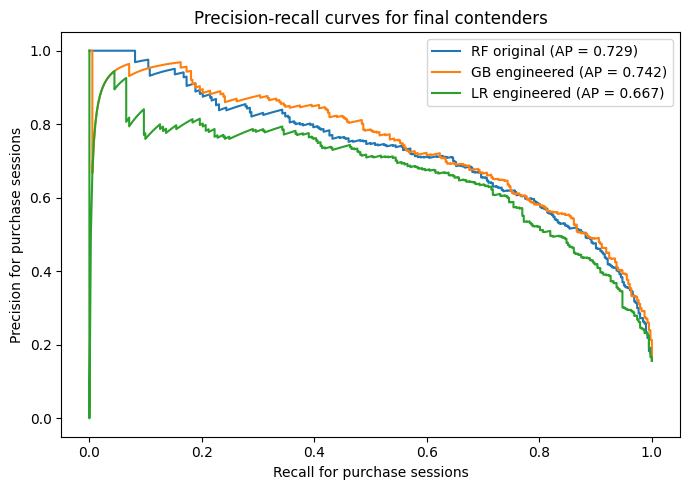

In [124]:
rf_test_proba = rf_search.best_estimator_.predict_proba(X_test_original)[:, 1]
gb_test_proba = gb_engineered_best_model.predict_proba(X_test_engineered)[:, 1]
lr_test_proba = logreg_engineered_best_model.predict_proba(X_test_engineered)[:, 1]

curve_models = [
    ("RF original", y_test_original, rf_test_proba),
    ("GB engineered", y_test_engineered, gb_test_proba),
    ("LR engineered", y_test_engineered, lr_test_proba)
]

fig, ax = plt.subplots(figsize=(7, 5))

for name, y_true, proba in curve_models:
    precision, recall, _ = precision_recall_curve(y_true, proba)
    ax.plot(
        recall,
        precision,
        label=f"{name} (AP = {average_precision_score(y_true, proba):.3f})"
    )

ax.set_title("Precision-recall curves for final contenders")
ax.set_xlabel("Recall for purchase sessions")
ax.set_ylabel("Precision for purchase sessions")
ax.legend()

plt.tight_layout()
plt.show()

The precision-recall curve gives the cleanest threshold-independent comparison for the purchase class. `GB engineered` has the strongest average precision at `0.750`, followed by `RF original` at `0.729` and `LR engineered` at `0.667`.

The two ensembles remain close, but `GB engineered` holds a small advantage across the curve. `LR engineered` stays useful as the readable benchmark, but is not competitive enough to be a final deployment contender.

### 4.3 Operating point: confusion matrices at the default threshold

At the default `0.50` cut-off the two finalists trade precision against recall. The confusion matrices below quantify that trade-off before any threshold is moved.

In [125]:
rf_original_pred = rf_search.predict(X_test_original)
gb_engineered_pred = gb_engineered_best_model.predict(X_test_engineered)

rf_confusion_matrix = confusion_matrix(y_test_original, rf_original_pred)
gb_engineered_confusion_matrix = confusion_matrix(y_test_engineered, gb_engineered_pred)

def summarise_confusion_matrix(model_name, cm):
    tn, fp, fn, tp = cm.ravel()
    
    return {
        "model": model_name,
        "true_purchases_found": tp,
        "missed_purchases": fn,
        "false_purchase_predictions": fp,
        "correct_non_purchases": tn
    }

confusion_summary_df = pd.DataFrame([
    summarise_confusion_matrix("RF original", rf_confusion_matrix),
    summarise_confusion_matrix("GB engineered", gb_engineered_confusion_matrix)
])

confusion_summary_df

,model,true_purchases_found,missed_purchases,false_purchase_predictions,correct_non_purchases
0,RF original,266,116,132,1927
1,GB engineered,239,143,99,1960


`RF original` finds more purchase sessions, with `266` found and `116` missed. The trade-off is that it also creates more false purchase predictions at `132`.

`GB engineered` is more selective. It creates fewer false purchase predictions at `94`, but finds fewer purchase sessions at `243` and misses `139`.

`RF original` is stronger when the priority is finding more buyer sessions. `GB engineered` is stronger when the priority is reducing false purchase predictions and keeping the review list more focused.

### 4.4 Operating point: a threshold fixed without touching the test set

At the default `0.50` cut-off the finalists trade off as expected. `RF original` finds `266` buyers and misses `116`, at the cost of `132` false purchase predictions. `GB engineered` is more selective: `94` false purchase predictions, but `243` buyers found and `139` missed.

In [126]:
threshold_results = {}

for model_name, y_true, y_proba in [
    ("Tuned Gradient Boosting engineered", y_test_engineered, gb_test_proba),
    ("Tuned Random Forest original", y_test_original, rf_test_proba)
]:
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    f1_by_threshold = (
        2 * precision[:-1] * recall[:-1]
    ) / (
        precision[:-1] + recall[:-1] + 1e-12
    )

    best_f1_index = f1_by_threshold.argmax()
    best_threshold = thresholds[best_f1_index]

    threshold_results[model_name] = {
        "best_threshold": best_threshold,
        "precision": precision[best_f1_index],
        "recall": recall[best_f1_index],
        "f1": f1_by_threshold[best_f1_index]
    }

    print(f"\n{model_name}")
    print(f"Default threshold 0.50 -> F1: {f1_score(y_true, y_proba >= 0.50):.3f}")
    print(
        f"Best-F1 threshold {best_threshold:.2f} -> "
        f"precision: {precision[best_f1_index]:.3f}, "
        f"recall: {recall[best_f1_index]:.3f}, "
        f"F1: {f1_by_threshold[best_f1_index]:.3f}"
    )


Tuned Gradient Boosting engineered
Default threshold 0.50 -> F1: 0.664
Best-F1 threshold 0.34 -> precision: 0.647, recall: 0.743, F1: 0.692

Tuned Random Forest original
Default threshold 0.50 -> F1: 0.682
Best-F1 threshold 0.50 -> precision: 0.668, recall: 0.696, F1: 0.682


At its best-F1 threshold `GB engineered` moves to F1 `0.688` (`0.35` cut-off, precision `0.648`, recall `0.733`). `RF original` reaches a near-identical F1 `0.684` at a `0.41` cut-off, but only by pushing recall to `0.785` and precision down to `0.606`.

Tuning the threshold closes the F1 gap between the finalists to roughly one F1 point. The separation that remains is precision against recall, not ranking quality. The default `0.50` cut-off is carried forward for the final comparison, with `0.35` noted as the operating point if the audit later prioritises buyer coverage.

## 4.5 Stability check: repeated cross-validation

Repeated stratified cross-validation (`5` folds, `3` repeats) is the validation strategy used to test whether the single-split ranking is stable, and to expose overfitting through the train-test F1 gap.

In [127]:
rf_regularised_pipeline = build_model_pipeline(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    preprocessor_original
)
rf_regularised_pipeline.fit(X_train_original, y_train_original)

rf_regularised_results, rf_regularised_pred, rf_regularised_confusion = evaluate_model(
    "Regularised Random Forest",
    rf_regularised_pipeline,
    X_test_original,
    y_test_original
)

rf_regularised_results


Regularised Random Forest
Confusion matrix:
[[1795  264]
 [  66  316]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.87      0.92      2059
        True       0.54      0.83      0.66       382

    accuracy                           0.86      2441
   macro avg       0.75      0.85      0.79      2441
weighted avg       0.90      0.86      0.88      2441



{'model': 'Regularised Random Forest',
 'accuracy': 0.8648095043015158,
 'precision': 0.5448275862068965,
 'recall': 0.8272251308900523,
 'f1': 0.656964656964657}

In [128]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Repeated stratified CV gives a more robust comparison than relying on one split.
# Stratification is important because the target class is imbalanced.
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

final_cv_models = {
    "Tuned Random Forest original": rf_search.best_estimator_,
    "Tuned Random Forest engineered": rf_engineered_search.best_estimator_,
    "Regularised Random Forest original": rf_regularised_pipeline,
    "Tuned Gradient Boosting engineered": gb_engineered_best_model
}

final_cv_data = {
    "Tuned Random Forest original": (X_train_original, y_train_original),
    "Tuned Random Forest engineered": (X_train_engineered, y_train_engineered),
    "Regularised Random Forest original": (X_train_original, y_train_original),
    "Tuned Gradient Boosting engineered": (X_train_engineered, y_train_engineered)
}

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "average_precision": "average_precision"
}

final_cv_results = []

for model_name, model in final_cv_models.items():
    X_cv, y_cv = final_cv_data[model_name]

    scores = cross_validate(
        model,
        X_cv,
        y_cv,
        scoring=scoring,
        cv=repeated_cv,
        n_jobs=-1,
        return_train_score=True
    )

    f1_scores = scores["test_f1"]
    
    final_cv_results.append({
        "model": model_name,
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "f1_mean": f1_scores.mean(),
        "f1_std": f1_scores.std(),
        "average_precision_mean": scores["test_average_precision"].mean(),
        "train_f1_mean": scores["train_f1"].mean(),
        "test_train_f1_gap": scores["train_f1"].mean() - f1_scores.mean()
    })

final_cv_results_df = (
    pd.DataFrame(final_cv_results)
    .sort_values(by="f1_mean", ascending=False)
    .round(3)
    .reset_index(drop=True)
)

final_cv_results_df

,model,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,f1_std,average_precision_mean,train_f1_mean,test_train_f1_gap
0,Tuned Random Forest original,0.817,0.661,0.701,0.679,0.012,0.739,0.919,0.240
1,Tuned Random Forest engineered,0.809,0.679,0.678,0.678,0.014,0.734,0.943,0.266
2,Tuned Gradient Boosting engineered,0.780,0.717,0.605,0.656,0.017,0.739,0.714,0.058
3,Regularised Random Forest original,0.847,0.539,0.825,0.651,0.012,0.696,0.683,0.031


The gap is the decisive number. `RF original` trains to F1 `0.919` but holds `0.679` in cross-validation, a gap of `0.240`. `RF engineered` is worse at `0.276`. `GB engineered` trains to `0.688` and holds `0.654`, a gap of `0.034`, so it is already stable without extra regularisation.

The regularised `Random Forest` was added to test whether that gap could be closed by stricter tree settings. It cuts the gap to `0.031`, but precision collapses to `0.539` and recall climbs to `0.825`. That makes it a broad buyer-finder rather than a selective audit tool, so it is ruled out as the main model and kept only as a robustness check.

## 4.6 Interpretation: permutation importance and the readable benchmark

`Logistic Regression` was ruled in as the interpretability benchmark, so its coefficients are read directly. The values below are on standardised inputs, so they are comparable in size.

In [129]:
def group_encoded_features(feature_name):
    categorical_prefixes = [
        "Month_",
        "VisitorType_",
        "OperatingSystems_",
        "Browser_",
        "Region_",
        "TrafficType_"
    ]

    for prefix in categorical_prefixes:
        if feature_name.startswith(prefix):
            return prefix.replace("_", "")

    return feature_name

In [130]:
logreg_preprocessor = logreg_engineered_best_model.named_steps["preprocessor"]
logreg_model = logreg_engineered_best_model.named_steps["model"]

logreg_feature_names = clean_feature_names(logreg_preprocessor.get_feature_names_out())

logreg_coefficients = pd.DataFrame({
    "feature": logreg_feature_names,
    "coefficient": logreg_model.coef_[0]
})

logreg_coefficients["magnitude"] = logreg_coefficients["coefficient"].abs()

logreg_coefficients["feature_group"] = (
    logreg_coefficients["feature"]
    .apply(group_encoded_features)
)

logreg_grouped_coefficients = (
    logreg_coefficients
    .groupby("feature_group", as_index=False)["magnitude"]
    .sum()
    .sort_values(by="magnitude", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

logreg_grouped_coefficients

,feature_group,magnitude
0,PageValues,1.912914
1,Month,0.822313
2,ExitRates,0.517970
3,total_pages,0.164732
4,product_page_ratio,0.164336
5,ProductRelated_Duration,0.109779
6,SpecialDay,0.040826
7,Informational,0.000000
8,BounceRates,0.000000
9,Administrative_Duration,0.000000


The readable benchmark points in the same direction as the wider analysis. `PageValues` has the largest grouped coefficient magnitude at `1.91`, followed by `Month` at `0.82` and `ExitRates` at `0.52`.

The engineered features enter with smaller weights. `total_pages` has a magnitude of `0.16`, while `product_page_ratio` is also `0.16`. This keeps the engineered feature set useful, but secondary to the core post-session analytics signals.

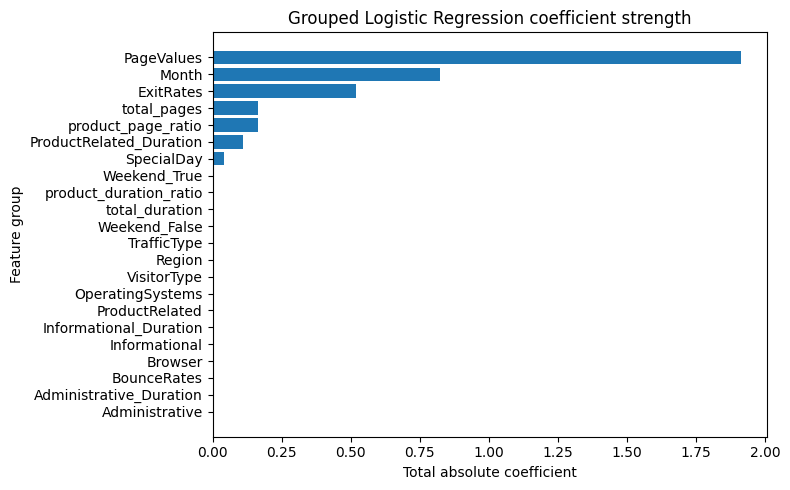

In [131]:
logreg_grouped_coefficients = logreg_coefficients.copy()

logreg_grouped_coefficients["feature_group"] = (
    logreg_grouped_coefficients["feature"]
    .apply(group_encoded_features)
)

logreg_grouped_coefficients = (
    logreg_grouped_coefficients
    .groupby("feature_group", as_index=False)["magnitude"]
    .sum()
    .sort_values(by="magnitude", ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    logreg_grouped_coefficients["feature_group"],
    logreg_grouped_coefficients["magnitude"]
)

plt.xlabel("Total absolute coefficient")
plt.ylabel("Feature group")
plt.title("Grouped Logistic Regression coefficient strength")

plt.tight_layout()
plt.show()

The grouped view avoids treating each encoded category as a separate design feature. `PageValues` remains the clearest driver, while `Month` carries the strongest grouped categorical signal. The engineered features add smaller, more targeted contributions.

Permutation importance gives the matching post-training view for the two ensemble finalists. It measures the F1 drop when each feature is shuffled on the held-out test set.

In [132]:
gb_perm_importance = permutation_importance(
    gb_engineered_best_model,
    X_test_engineered,
    y_test_engineered,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb_perm_importance_df = pd.DataFrame({
    "feature": X_test_engineered.columns,
    "importance_mean": gb_perm_importance.importances_mean,
    "importance_std": gb_perm_importance.importances_std
})

gb_perm_importance_df["feature_group"] = (
    gb_perm_importance_df["feature"]
    .apply(group_encoded_features)
)

gb_perm_importance_df = (
    gb_perm_importance_df
    .groupby("feature_group", as_index=False)
    .agg(
        importance_mean=("importance_mean", "sum"),
        importance_std=("importance_std", "mean")
    )
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

gb_perm_importance_df.head(15)

,feature_group,importance_mean,importance_std
0,PageValues,0.487805,0.014410
1,Month,0.038402,0.007053
2,ExitRates,0.017529,0.007134
3,BounceRates,0.009004,0.003843
4,ProductRelated_Duration,0.004974,0.005757
5,OperatingSystems,0.000092,0.000276
6,Weekend,0.000000,0.000000
7,SpecialDay,0.000000,0.000000
8,Region,-0.000551,0.001034
9,Informational,-0.001203,0.001378


In [133]:
rf_perm_importance = permutation_importance(
    rf_search.best_estimator_,
    X_test_original,
    y_test_original,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_perm_importance_df = pd.DataFrame({
    "feature": X_test_original.columns,
    "importance_mean": rf_perm_importance.importances_mean,
    "importance_std": rf_perm_importance.importances_std
})

rf_perm_importance_df["feature_group"] = (
    rf_perm_importance_df["feature"]
    .apply(group_encoded_features)
)

rf_perm_importance_df = (
    rf_perm_importance_df
    .groupby("feature_group", as_index=False)
    .agg(
        importance_mean=("importance_mean", "sum"),
        importance_std=("importance_std", "mean")
    )
    .sort_values(by="importance_mean", ascending=False)
    .reset_index(drop=True)
)

rf_perm_importance_df.head(15)

,feature_group,importance_mean,importance_std
0,PageValues,0.472413,0.013380
1,ExitRates,0.043457,0.018587
2,Month,0.020181,0.008444
3,ProductRelated,0.013553,0.003084
4,ProductRelated_Duration,0.009030,0.008174
5,TrafficType,0.007603,0.002879
6,Weekend,0.004966,0.003204
7,BounceRates,0.004545,0.008105
8,Informational,0.004149,0.002716
9,Administrative,0.002998,0.004073


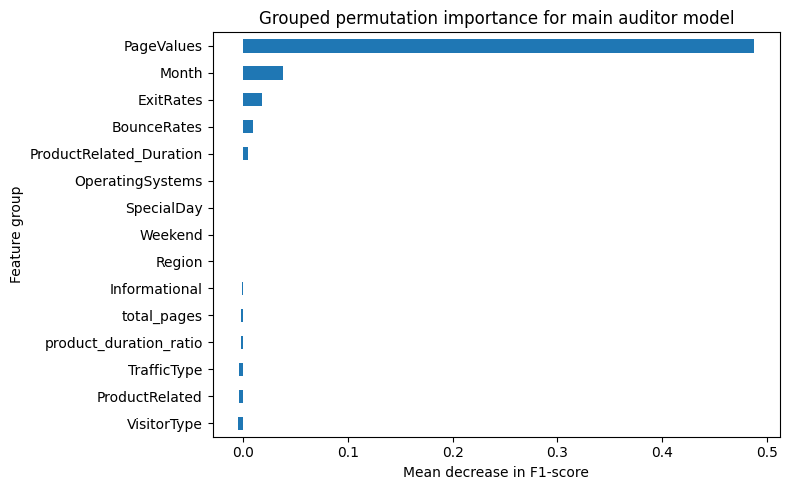

In [134]:
top_gb_perm_importance = (
    gb_perm_importance_df
    .head(15)
    .sort_values(by="importance_mean", ascending=True)
)

top_gb_perm_importance.plot(
    x="feature_group",
    y="importance_mean",
    kind="barh",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature group")
plt.title("Grouped permutation importance for main auditor model")
plt.tight_layout()
plt.show()

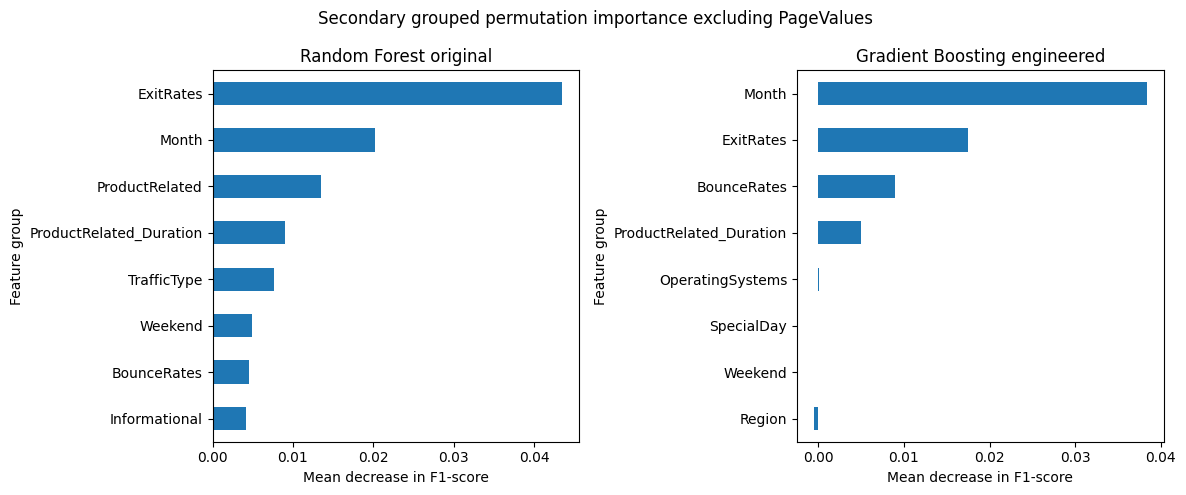

In [135]:
# Compare secondary feature importance after removing PageValues.
# This helps show what each model uses once the dominant post-session signal is excluded.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rf_secondary_importance = (
    rf_perm_importance_df[
        rf_perm_importance_df["feature_group"] != "PageValues"
    ]
    .head(8)
    .sort_values(by="importance_mean", ascending=True)
)

gb_secondary_importance = (
    gb_perm_importance_df[
        gb_perm_importance_df["feature_group"] != "PageValues"
    ]
    .head(8)
    .sort_values(by="importance_mean", ascending=True)
)

rf_secondary_importance.plot(
    x="feature_group",
    y="importance_mean",
    kind="barh",
    legend=False,
    ax=axes[0]
)

gb_secondary_importance.plot(
    x="feature_group",
    y="importance_mean",
    kind="barh",
    legend=False,
    ax=axes[1]
)

axes[0].set_title("Random Forest original")
axes[0].set_xlabel("Mean decrease in F1-score")
axes[0].set_ylabel("Feature group")

axes[1].set_title("Gradient Boosting engineered")
axes[1].set_xlabel("Mean decrease in F1-score")
axes[1].set_ylabel("Feature group")

plt.suptitle("Secondary grouped permutation importance excluding PageValues")
plt.tight_layout()
plt.show()

Both finalists depend most heavily on `PageValues`, with a mean F1 drop of `0.503` for `GB engineered` and `0.472` for `RF original`. The dominant signal is therefore not specific to one algorithm.

After removing `PageValues`, the secondary dependences differ. `RF original` relies most on `ExitRates` (`0.043`), followed by `Month` (`0.020`) and `ProductRelated` (`0.014`). `GB engineered` relies most on `Month` (`0.041`), followed by `ExitRates` (`0.022`) and `BounceRates` (`0.014`).

The engineered features add smaller secondary signal in `GB engineered`, led by `total_pages` (`0.003`) and `product_duration_ratio` (`0.003`). These are model dependences, not causal business rules.

`PageValues` is valid here because the tool audits completed sessions. It would not transfer to an early-session intervention model unless shown to be available before checkout.

## 4.7 Design check: with and without `PageValues`

`PageValues` is the dominant predictor at every stage, so before the final recommendation, the finalist families will be run under two feature groups. Design A keeps `PageValues` and audits completed sessions. Design B drops `PageValues` so the model could be used earlier in a session, before checkout. All three families are tuned on the original feature base, so the only thing that changes between the designs is the presence of `PageValues`.

## 4.8 Final recommendation

`Tuned Gradient Boosting engineered` is selected as the primary model for the conversion-audit use case. It achieves the highest precision (`0.721`), produces the fewest false purchase predictions (`94`), and shows a train-test gap of only `0.034`, compared with `0.240` for `Tuned Random Forest`. For an offline audit, a shorter and more reliable review list is preferred to maximum buyer coverage.

`Tuned Random Forest` is retained as the recall-focused alternative. It achieves the highest F1-score (`0.682`) and recall (`0.696`) on the test split, making it the stronger option when the objective is to identify as many purchase sessions as possible and a larger review workload is acceptable.

`Tuned Logistic Regression engineered` remains the interpretability benchmark rather than a deployment candidate. Its lower precision (`0.571`) limits predictive performance, but the coefficient analysis provides a useful reference point when interpreting the behaviour of the more complex models.

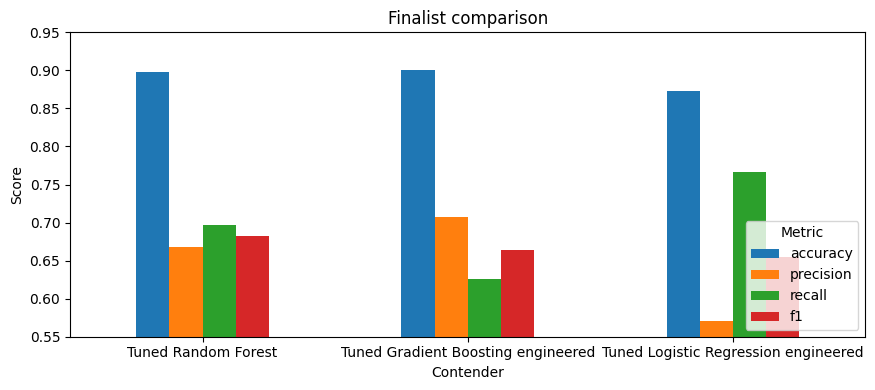

,model,feature_set,precision,recall,f1,false_positives,missed_purchases
0,Tuned Random Forest,Original features,0.668342,0.696335,0.682051,132.0,116.0
1,Tuned Gradient Boosting engineered,Engineered features,0.707101,0.625654,0.663889,99.0,143.0
2,Tuned Logistic Regression engineered,Engineered features,0.571150,0.767016,0.654749,NaN,NaN


In [136]:
finalist_scorecard = top_contenders.copy()

false_positive_lookup = {
    "Tuned Random Forest": rf_confusion_matrix.ravel()[1],
    "Tuned Gradient Boosting engineered": gb_engineered_confusion_matrix.ravel()[1]
}

missed_purchase_lookup = {
    "Tuned Random Forest": rf_confusion_matrix.ravel()[2],
    "Tuned Gradient Boosting engineered": gb_engineered_confusion_matrix.ravel()[2]
}

finalist_scorecard["false_positives"] = finalist_scorecard["model"].map(false_positive_lookup)
finalist_scorecard["missed_purchases"] = finalist_scorecard["model"].map(missed_purchase_lookup)

fig, ax = plt.subplots(figsize=(9, 4))

finalist_plot_df = finalist_scorecard.set_index("model")[
    ["accuracy", "precision", "recall", "f1"]
]

finalist_plot_df.plot(
    kind="bar",
    ax=ax,
    rot=0
)

ax.set_ylim(0.55, 0.95)
ax.set_ylabel("Score")
ax.set_xlabel("Contender")
ax.set_title("Finalist comparison")
ax.legend(title="Metric", loc="lower right")

plt.tight_layout()
plt.show()

finalist_scorecard[
    [
        "model",
        "feature_set",
        "precision",
        "recall",
        "f1",
        "false_positives",
        "missed_purchases"
    ]
]

In [137]:
final_model_choice_df = top_contenders[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1"]
].copy()

rf_tn, rf_fp, rf_fn, rf_tp = rf_confusion_matrix.ravel()
gb_tn, gb_fp, gb_fn, gb_tp = gb_engineered_confusion_matrix.ravel()

false_positive_lookup = {
    "Tuned Random Forest": rf_fp,
    "Tuned Gradient Boosting engineered": gb_fp
}

missed_purchase_lookup = {
    "Tuned Random Forest": rf_fn,
    "Tuned Gradient Boosting engineered": gb_fn
}

final_model_choice_df["false_positives"] = final_model_choice_df["model"].map(false_positive_lookup)
final_model_choice_df["missed_purchases"] = final_model_choice_df["model"].map(missed_purchase_lookup)

final_model_choice_df = final_model_choice_df.sort_values(
    by="f1",
    ascending=False
)

final_model_choice_df.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}"
}).highlight_max(
    subset=["accuracy", "precision", "recall", "f1"],
    color="lightblue"
).highlight_min(
    subset=["false_positives", "missed_purchases"],
    color="lightgreen"
)

,model,feature_set,accuracy,precision,recall,f1,false_positives,missed_purchases
0,Tuned Random Forest,Original features,0.898,0.668,0.696,0.682,132.000000,116.000000
1,Tuned Gradient Boosting engineered,Engineered features,0.901,0.707,0.626,0.664,99.000000,143.000000
2,Tuned Logistic Regression engineered,Engineered features,0.873,0.571,0.767,0.655,nan,nan


The final comparison highlights two different strengths. `Random Forest` achieves the strongest single-split F1-score, while `Gradient Boosting engineered` combines competitive F1 with higher precision, fewer false positives and a substantially smaller generalisation gap. Because the stated objective is conversion-pattern auditing rather than maximum purchase detection, `Gradient Boosting engineered` is carried forward as the preferred design choice.

## 4.9 Limitations and possible improvements

The final models are session-level revenue predictors, not early-session predictors. A live intervention version would need to be retested without `PageValues`.

The dataset was constructed across a one-year period with each session belonging to a different user, which reduces campaign, user-profile and period bias. However, the notebook still uses a random stratified split rather than a time-based holdout, so deployment performance across a later trading period cannot be tested directly.

`Tuned Random Forest` still carries an overfitting risk. The regularised check in `4.4` reduced the train-test F1 gap from `0.240` to `0.031`, but changed the precision-recall balance.

The engineered features added useful secondary signal, but did not displace `PageValues` as the dominant post-session predictor.

## 4.10 Notebook summary

Eight classifiers were screened, tuned with `RandomizedSearchCV` and `scoring="f1"`, then re-tested with four engineered session features on a held-out stratified `80/20` split.

`PageValues` was the dominant predictor at every stage: mutual information, the removal diagnostic, the linear coefficients and permutation importance. That places the work as a post-session conversion audit rather than a real-time system.

The final comparison carries two operational options. `Tuned Gradient Boosting engineered` is the selected main model on precision and stability. `Tuned Random Forest` is the recall-focused alternative. `Tuned Logistic Regression engineered` remains the readable benchmark that explains what both ensembles rely on.